## 0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn

print(torch.__version__)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

2.1.2
cuda


## 2. Data Visualization

Random image path: ../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/X/X (962).jpg
Image Class: X
Image Height: 200
Image Width: 200


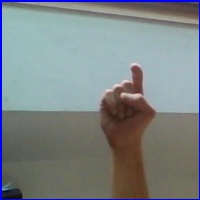

In [3]:
from pathlib import Path
import os
import random
from PIL import Image

# random.seed(42)
image_path = Path("../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/")
image_path_list = list(image_path.glob("*/*/*.jpg"))
# print(len(image_path_list))
random_image_path = random.choice(image_path_list)
# print(random_image_path)
# the image class is the name of the directory where iamges resides
image_class = random_image_path.parent.stem
# print(image_class)

img = Image.open(random_image_path)

# Print metadata
print(f'Random image path: {random_image_path}')
print(f'Image Class: {image_class}')
print(f'Image Height: {img.height}')
print(f'Image Width: {img.width}')
img

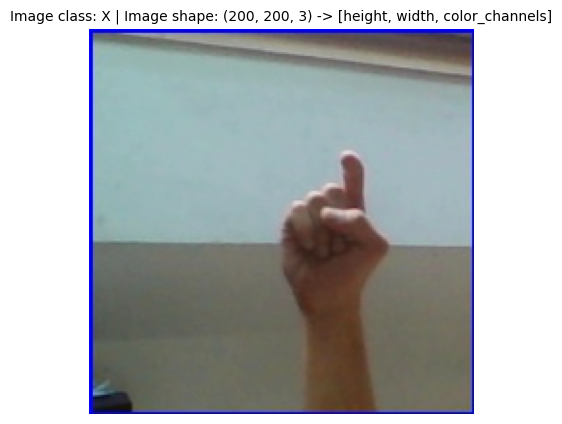

In [4]:
# Visualizing using matplotliib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
fig = plt.figure(figsize=(6, 5))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]", fontsize = 10)
plt.axis(False)
plt.show()

In [5]:
img_as_array

array([[[  0,   4, 253],
        [  0,   8, 254],
        [  0,   0, 240],
        ...,
        [  9,   0, 249],
        [  0,   0, 248],
        [  0,   3, 252]],

       [[  0,   8, 255],
        [  0,   0, 230],
        [  7,  10, 209],
        ...,
        [ 10,   3, 194],
        [  9,   9, 217],
        [  0,   1, 218]],

       [[  1,   0, 243],
        [ 12,   9, 212],
        [ 89,  90, 206],
        ...,
        [ 84,  76, 151],
        [ 71,  68, 197],
        [ 15,  14, 170]],

       ...,

       [[  6,   0, 250],
        [  8,   5, 200],
        [ 17,  17, 107],
        ...,
        [103, 102, 116],
        [ 98, 102, 191],
        [  8,  13, 139]],

       [[  2,   2, 248],
        [  3,   3, 213],
        [ 10,   9, 147],
        ...,
        [100, 104, 195],
        [ 87,  95, 230],
        [  5,  15, 174]],

       [[  0,   1, 246],
        [  1,   4, 221],
        [ 12,  11, 175],
        ...,
        [ 10,  15, 145],
        [  5,  13, 173],
        [  0,  12, 186]]

## 3. Transforming data

In [6]:
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

print(torchvision.__version__)

# Transform image
data_transform = transforms.Compose([
    transforms.Resize(size = (128, 128)),         # Resize our images to 128X128
    transforms.ToTensor()
])


transformed_data = data_transform(img)
transformed_data, transformed_data.shape, transformed_data.dtype

0.16.2


(tensor([[[0.0000, 0.0078, 0.0196,  ..., 0.0314, 0.0314, 0.0078],
          [0.0196, 0.2000, 0.2745,  ..., 0.2549, 0.2392, 0.1098],
          [0.0353, 0.2824, 0.3882,  ..., 0.3137, 0.2902, 0.1412],
          ...,
          [0.0235, 0.0902, 0.1176,  ..., 0.4471, 0.4275, 0.1882],
          [0.0235, 0.0549, 0.0667,  ..., 0.4235, 0.4000, 0.1725],
          [0.0039, 0.0353, 0.0471,  ..., 0.1843, 0.1725, 0.0627]],
 
         [[0.0235, 0.0196, 0.0157,  ..., 0.0078, 0.0078, 0.0118],
          [0.0157, 0.2039, 0.2863,  ..., 0.2196, 0.2118, 0.1020],
          [0.0118, 0.2980, 0.4314,  ..., 0.2784, 0.2706, 0.1373],
          ...,
          [0.0157, 0.0902, 0.1255,  ..., 0.4353, 0.4235, 0.2000],
          [0.0078, 0.0510, 0.0667,  ..., 0.4235, 0.4039, 0.1922],
          [0.0078, 0.0314, 0.0392,  ..., 0.1961, 0.1922, 0.1020]],
 
         [[0.9804, 0.9059, 0.8706,  ..., 0.8784, 0.8980, 0.9294],
          [0.9176, 0.7804, 0.6471,  ..., 0.5647, 0.6392, 0.7294],
          [0.8863, 0.6667, 0.4667,  ...,

## 4. Loading data with ImageFolder and Split into Train and Test Data

In [7]:
# Setup source directory
source_dir = '../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/'

source_data = datasets.ImageFolder(root = source_dir,
                                  transform = data_transform, # Transforms input data into tensors
                                  target_transform = None)    # Transform labels into none

source_data

Dataset ImageFolder
    Number of datapoints: 223074
    Root location: ../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=warn)
               ToTensor()
           )

In [8]:
from torch.utils.data import random_split

train_size = int(0.8 * len(source_data))
test_size = len(source_data) - train_size

# Split the dataset into train and test sets
train_data, test_data = random_split(source_data, [train_size, test_size])

print(f"Train set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

Train set size: 178459
Test set size: 44615


In [9]:
# Get class names as list and dict 
class_names = source_data.classes
class_dict = source_data.class_to_idx
class_dict

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 'del': 26,
 'nothing': 27,
 'space': 28}

In [10]:
# Index on the train_data Dataset to get a single iamge and label
img, label = train_data[0][0], train_data[0][1]

img, img.dtype, label, type(label), class_names[label]

(tensor([[[0.0000, 0.0118, 0.0157,  ..., 0.0392, 0.0353, 0.0078],
          [0.0196, 0.2000, 0.2745,  ..., 0.3725, 0.3725, 0.1608],
          [0.0314, 0.3647, 0.5059,  ..., 0.4588, 0.4471, 0.2078],
          ...,
          [0.0235, 0.2118, 0.3020,  ..., 0.6039, 0.5804, 0.2510],
          [0.0196, 0.2078, 0.2941,  ..., 0.5843, 0.5608, 0.2353],
          [0.0078, 0.0941, 0.1412,  ..., 0.2510, 0.2353, 0.0902]],
 
         [[0.0118, 0.0118, 0.0118,  ..., 0.0078, 0.0118, 0.0157],
          [0.0118, 0.1804, 0.2471,  ..., 0.3255, 0.3373, 0.1569],
          [0.0078, 0.3373, 0.4549,  ..., 0.3882, 0.3882, 0.1804],
          ...,
          [0.0157, 0.2196, 0.3098,  ..., 0.5725, 0.5569, 0.2510],
          [0.0118, 0.2078, 0.3020,  ..., 0.5686, 0.5529, 0.2431],
          [0.0118, 0.0980, 0.1451,  ..., 0.2588, 0.2471, 0.1216]],
 
         [[0.9765, 0.9216, 0.8745,  ..., 0.8706, 0.8902, 0.9216],
          [0.9255, 0.7373, 0.5686,  ..., 0.6745, 0.7686, 0.7843],
          [0.8863, 0.6471, 0.4078,  ...,

In [11]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)
img.shape, img_permute.shape

(torch.Size([3, 128, 128]), torch.Size([128, 128, 3]))

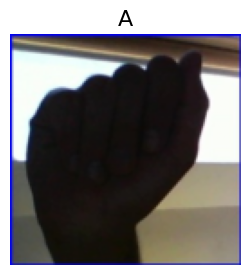

In [12]:
# Plot the image
plt.figure(figsize = (3, 3))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize = 16); 

## 5. Turn loaded images into Dataloaders

In [13]:
# Train and test dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 192
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              num_workers = 1,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)

len(train_dataloader), len(test_dataloader)

(930, 233)

In [14]:
img, label = next(iter(train_dataloader))

img.shape, label.shape     # {img.shape} -> [batch_size, color_channels, height, width]

(torch.Size([192, 3, 128, 128]), torch.Size([192]))

## 6. Transfer Learning using `EfficientNetB0`

In [15]:
!pip install efficientnet_pytorch torchinfo

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16428 sha256=d24a5721ddf1c229584ccfe05be479be5cccb4b7f5ed7e994cf99b657e088782
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [16]:
from efficientnet_pytorch import EfficientNet
from torchinfo import summary

num_classes = len(class_names)    # Number of classes

# Instantiate the EfficientNet model
model = EfficientNet.from_pretrained('efficientnet-b0').to(device)
model._fc = nn.Linear(model._fc.in_features, num_classes)  

summary(model=model,
        input_size=(192, 3, 128, 128),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 154MB/s] 


Loaded pretrained weights for efficientnet-b0


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [192, 3, 128, 128]   [192, 29]            --                   True
├─Conv2dStaticSamePadding (_conv_stem)                       [192, 3, 128, 128]   [192, 32, 64, 64]    864                  True
│    └─ZeroPad2d (static_padding)                            [192, 3, 128, 128]   [192, 3, 129, 129]   --                   --
├─BatchNorm2d (_bn0)                                         [192, 32, 64, 64]    [192, 32, 64, 64]    64                   True
├─MemoryEfficientSwish (_swish)                              [192, 32, 64, 64]    [192, 32, 64, 64]    --                   --
├─ModuleList (_blocks)                                       --                   --                   --                   True
│    └─MBConvBlock (0)                                       [192, 32, 64, 64]    [192, 16, 64, 

In [17]:
# Trying forward pass to check the model
model(img.to(device))

tensor([[ 3.4723e-01,  2.8738e-01, -3.2850e-01,  ...,  1.3750e-01,
         -2.8572e-01,  2.0263e-01],
        [-1.8856e-02,  1.6867e-01, -1.7457e-01,  ..., -3.6616e-02,
          4.3879e-02, -1.0015e-01],
        [ 1.1496e-01, -9.2184e-02,  1.9595e-02,  ...,  1.4525e-01,
          7.0178e-02,  2.7308e-02],
        ...,
        [ 7.7161e-02,  1.1232e-01,  7.6943e-02,  ..., -6.9502e-02,
         -1.1276e-01,  3.4332e-02],
        [-3.9197e-01, -3.3254e-01, -2.8133e-01,  ...,  2.2657e-01,
          1.8815e-04, -3.0881e-01],
        [-2.9688e-01,  4.7128e-02, -1.4417e-01,  ..., -6.6579e-02,
          4.8446e-02,  3.4483e-01]], device='cuda:0', grad_fn=<AddmmBackward0>)

## 7. Create Train/Test Loop Function

In [18]:
def train_step(model, dataloader, loss_fn, optimizer):
    model.train()
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn):
    model.eval()
    test_loss, test_acc = 0, 0

    # Turn on inference
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [19]:
from tqdm.auto import tqdm

def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs):

  # Create a empty results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss":[],
             "test_acc": []}

  # Loop through training and testing steps for no of epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model = model,
                                       dataloader = train_dataloader,
                                       optimizer = optimizer,
                                       loss_fn = loss_fn)

    test_loss, test_acc = test_step(model = model,
                                     dataloader = test_dataloader,
                                     loss_fn = loss_fn)

    print(f'Epoch: {epoch} | Train loss: {train_loss:.4f} - Train acc: {(train_acc*100):.2f}% -  Test loss: {test_loss:.4f} - Test acc: {(test_acc*100):.2f}%')

    # Update results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

## 8. Train and Evaluate the Model

In [20]:
# Setup loss functions and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr=0.001)

In [21]:
# Set random seed
# torch.manual_seed(42)
EPOCHS = 5

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model
model_results = train(model = model,
                      train_dataloader = train_dataloader,
                      test_dataloader = test_dataloader,
                      optimizer = optimizer,
                      loss_fn = loss_fn,
                      epochs = EPOCHS)

# End the timer and print duration of training
end_time = timer()
print(f'Total Train Time: {end_time - start_time:.3f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 0.0928 - Train acc: 97.51% -  Test loss: 0.0187 - Test acc: 99.43%
Epoch: 1 | Train loss: 0.0202 - Train acc: 99.41% -  Test loss: 0.0324 - Test acc: 98.98%
Epoch: 2 | Train loss: 0.0137 - Train acc: 99.61% -  Test loss: 0.0132 - Test acc: 99.62%
Epoch: 3 | Train loss: 0.0139 - Train acc: 99.61% -  Test loss: 0.0551 - Test acc: 98.46%
Epoch: 4 | Train loss: 0.0084 - Train acc: 99.77% -  Test loss: 0.0238 - Test acc: 99.38%
Total Train Time: 4229.344 seconds


## 9. Plot loss curves and accuracy curves

In [22]:
# Get the model key results
model_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [23]:
def plot_loss_curves(results):
    """ Plots training curves of a results dictionary """

    # Get results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

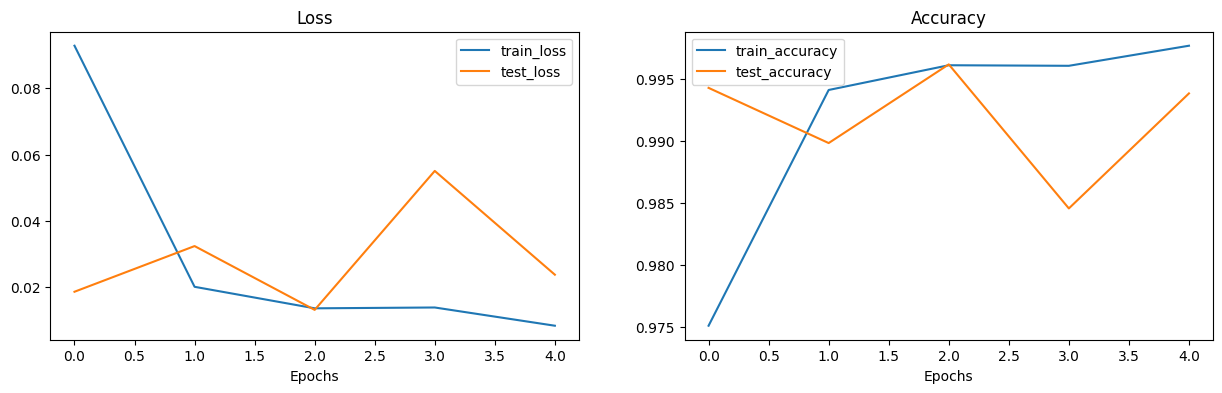

In [24]:
plot_loss_curves(model_results)

## 10. Saving Model

In [25]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# Create model save path
MODEL_NAME = "ASL_HandSignLang_EfficientNetB0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/ASL_HandSignLang_EfficientNetB0.pth


## 12. Making Predictions on Loaded Model

In [26]:
loaded_model = EfficientNet.from_pretrained('efficientnet-b0').to('cpu')
loaded_model._fc = nn.Linear(model._fc.in_features, 29)

loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# print(f"Loaded model:\n{loaded_model}")
print(f"Model on device:\n{next(loaded_model.parameters()).device}")

Loaded pretrained weights for efficientnet-b0
Model on device:
cpu


In [27]:
def make_predictions(model, data, device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim = 0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)
      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [66]:
import random
# random.seed(42)

test_samples = []
test_labels = []
# test_targets_tensor = torch.tensor(test_data.targets)
for sample, label in random.sample(list(test_data), k = 30):
  test_samples.append(sample)
  test_labels.append(label)

In [68]:
loaded_pred_probs = make_predictions(loaded_model,
                                     test_samples,
                                     device)

loaded_pred_classes = loaded_pred_probs.argmax(dim = 1)

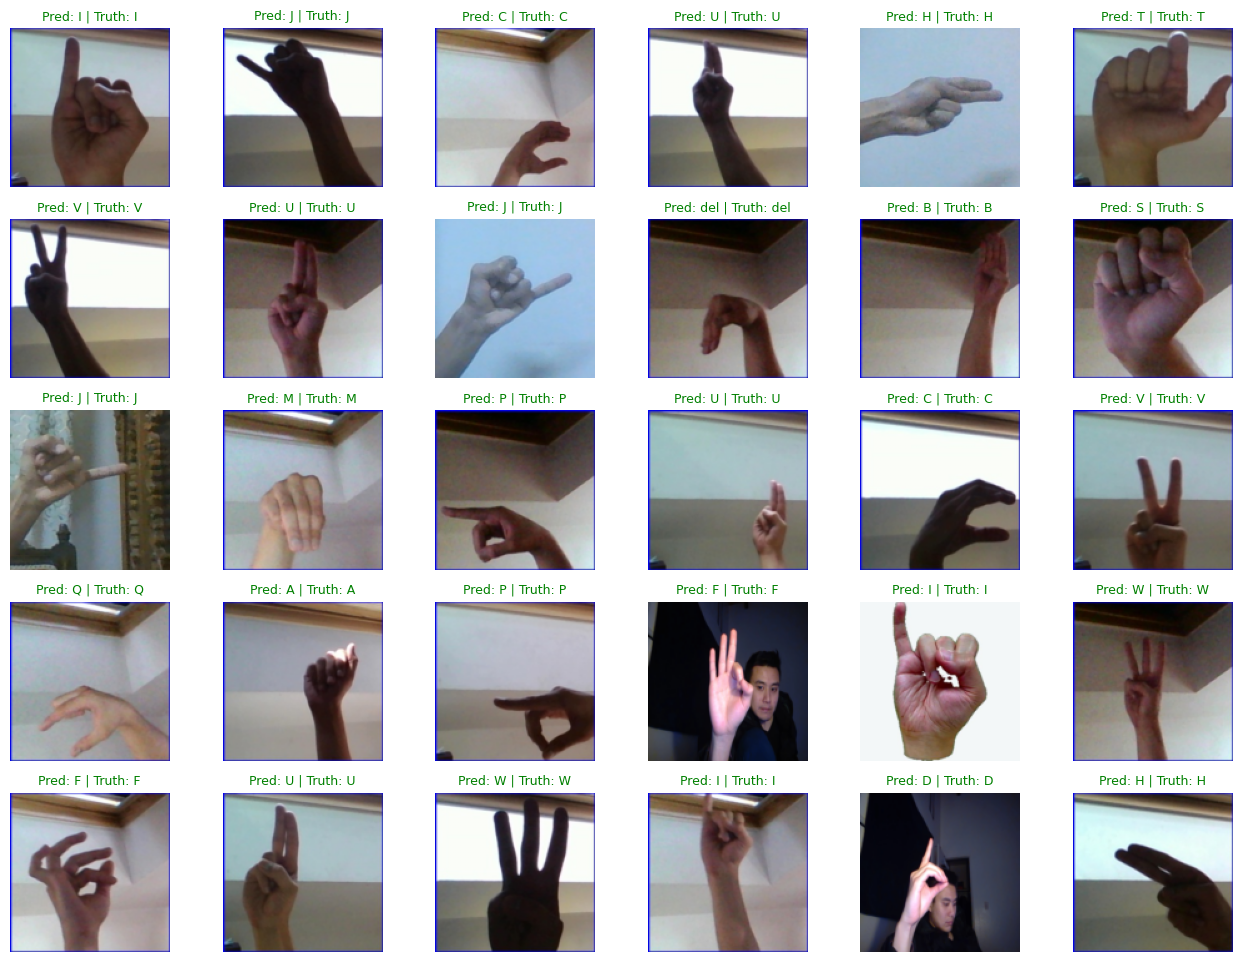

In [30]:
plt.figure(figsize=(16, 12))
nrows, ncols = 5, 6

for i, sample in enumerate(test_samples):
  class_name = np.array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
                      'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
                      'del', 'nothing', 'space'])
  plt.subplot(nrows, ncols, i + 1)
  normalized_sample = sample.permute(1, 2, 0).numpy()
  # normalized_sample = normalized_sample / 255.0
  plt.imshow(normalized_sample)

  pred_label = class_name[loaded_pred_classes[i]]
  truth_label = class_name[test_labels[i]]
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"  
    
  if pred_label == truth_label:
      plt.title(title_text, fontsize=9, c="g")
  else:
      plt.title(title_text, fontsize=9, c="r")

  plt.axis(False);